# Прогноз EPA combined fuel consumption

SE-2421 — Tsybus Nikita и Bakytzhan Kassymgali. Сравниваем характеристики бензиновых автомобилей и SUV рынка США. Цель — стандартизованная EPA combined оценка в L/100 km.

**Текущий notebook — технический прогон на ограниченном реальном сборе.** До полного Midterm нужны минимум 1 000 валидных конфигураций, audit покрытия и data card. Source: https://www.fueleconomy.gov/feg/ws/index.shtml. Notebook работает offline и заново обучает модели во временной папке.

In [1]:
%matplotlib inline
from pathlib import Path
import tempfile
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from fuel_consumption.utils import project_root, load_config
from fuel_consumption.split import read_dataset, load_frozen_split
from fuel_consumption.train import run_midterm
ROOT = project_root()
DATASET = ROOT / 'examples/smoke/data/processed/vehicles.parquet'
SPLIT_DIR = ROOT / 'examples/smoke/data/splits'
ALLOW_SMALL = True
CONFIG = ROOT / "configs/project.json"
config = load_config(CONFIG)
df = read_dataset(DATASET)
manifest, split_info = load_frozen_split(DATASET, CONFIG, SPLIT_DIR)
merged = df.merge(manifest[["vehicle_id", "split", "cv_fold"]], on="vehicle_id", validate="one_to_one")
train = merged.loc[merged["split"].eq("train")].copy()
print({"rows": len(df), "train": len(train), "test": len(df)-len(train), "development": len(df)<1000})
display(df.groupby(["model_year", "manufacturer"]).size().rename("rows").to_frame())

{'rows': 146, 'train': 116, 'test': 30, 'development': True}


rows
model_year manufacturer      
2015       Ford            18
           Honda           21
           Toyota          17
2020       Ford            13
           Honda           19
           Toyota          13
2025       Ford            13
           Honda           15
           Toyota          17

## Данные и очистка

Одна строка — отдельный EPA vehicle ID после проверок source, powertrain, класса и target. Оригинальный текст сохранен для Final. Очистка и причины исключения находятся в `examples\smoke\data\interim`. Таблица ниже показывает реальные пропуски. Target не импутируется; comb08 преобразуется формулой 235.2145833333333 / MPG. MPG, стоимость, emissions, scores и идентификаторы не входят в predictors.

In [2]:
feature_cols = config["features"]["numeric"] + config["features"]["categorical"]
display(df[feature_cols + ["model_name", "engine_description"]].isna().mean().rename("missing_fraction").to_frame())
display(pd.Series(split_info).to_frame("value"))

,missing_fraction
model_year,0.000000
displacement_l,0.000000
cylinders,0.000000
manufacturer,0.000000
transmission,0.000000
drivetrain,0.000000
vehicle_class,0.000000
model_name,0.000000
engine_description,0.321918


,value
schema_version,1.0
frozen_at_utc,2026-10-09T00:40:42.212564+00:00
dataset_path,C:\Users\Nikeka\Documents\Codex\2026-10-09\gro...
dataset_sha256,f03e84f68e8e15daab31e6a1ce6e1e0886e5c33bac95a5...
config_sha256,fcd05f90aed6318fe9245272f5f23202ee4bb50c23388a...
artifact_sha256,{'group_mapping.csv': 'fe12855deae3bc02da50c19...
alias_map_sha256,None
group_definition,normalized manufacturer + base_model; fallback...
method,GroupShuffleSplit
test_group_fraction,0.2


## EDA на training split

Исследуем форму распределения target, связь с displacement и покрытие классов. Эти графики помогают обосновать median baseline, сравнение линейной и нелинейных моделей и группы последующего анализа ошибок. Небольшой ограниченный snapshot не отражает весь рынок.

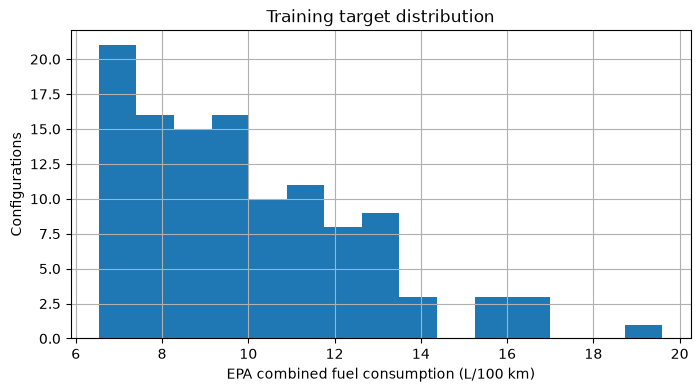

Median: 9.409 Mean: 9.976
Median dummy is the constant baseline for absolute error.


In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
train["target_l100km"].hist(bins=15, ax=ax)
ax.set(xlabel="EPA combined fuel consumption (L/100 km)", ylabel="Configurations", title="Training target distribution")
plt.show()
print("Median:", round(train.target_l100km.median(), 3), "Mean:", round(train.target_l100km.mean(), 3))
print("Median dummy is the constant baseline for absolute error.")

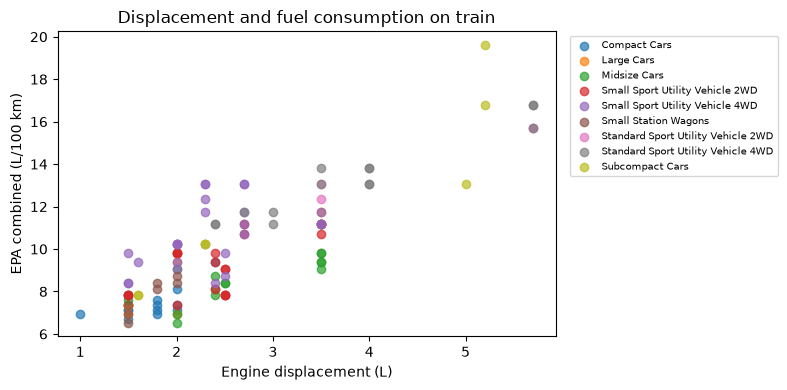

Train Pearson correlation: 0.8500307739497448
This is association; we compare LR, KNN and tree to check model form.


In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
for label, group in train.groupby("vehicle_class"):
    ax.scatter(group.displacement_l, group.target_l100km, label=label, alpha=.7)
ax.set(xlabel="Engine displacement (L)", ylabel="EPA combined (L/100 km)", title="Displacement and fuel consumption on train")
ax.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout(); plt.show()
print("Train Pearson correlation:", train[["displacement_l", "target_l100km"]].corr().iloc[0,1])
print("This is association; we compare LR, KNN and tree to check model form.")

,count,median,mean
vehicle_class,,,
Small Sport Utility Vehicle 4WD,25,10.226721,10.660426
Small Sport Utility Vehicle 2WD,20,9.227649,9.209695
Midsize Cars,15,8.711651,8.681061
Standard Sport Utility Vehicle 4WD,15,13.067477,13.156280
Compact Cars,14,7.239085,7.433306
Large Cars,9,7.350456,8.673126
Small Station Wagons,7,8.110848,7.775116
Subcompact Cars,7,10.226721,12.229164
Standard Sport Utility Vehicle 2WD,4,14.374225,14.202284


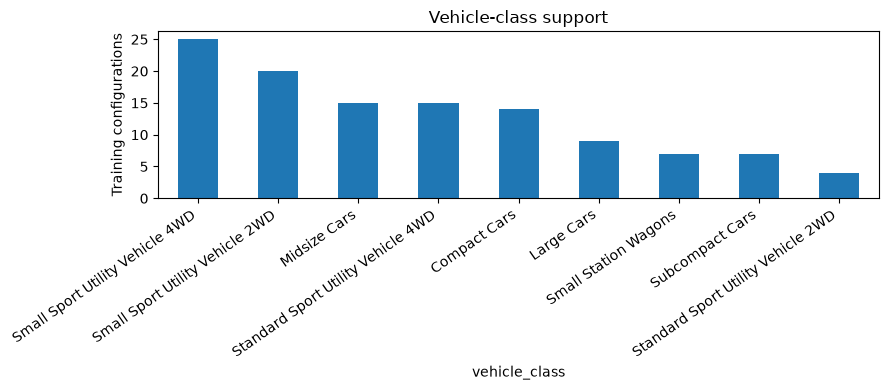

Classes with few rows need explicitly qualified error estimates.


In [5]:
class_summary = train.groupby("vehicle_class").target_l100km.agg(["count", "median", "mean"]).sort_values("count", ascending=False)
display(class_summary)
fig, ax = plt.subplots(figsize=(9, 4))
class_summary["count"].plot.bar(ax=ax)
ax.set(ylabel="Training configurations", title="Vehicle-class support")
plt.xticks(rotation=35, ha="right"); plt.tight_layout(); plt.show()
print("Classes with few rows need explicitly qualified error estimates.")

## Фиксированные модели и train CV

Dummy median, Linear Regression, KNN k=15 с distance weights и Decision Tree depth=8/min leaf=10. Числа импутируются и масштабируются, категории кодируются в sklearn pipeline внутри каждого fold. Семейства make + baseModel разделены между train/test и CV folds. Победитель выбирается по mean train CV MAE до вычисления test scores. Std по folds не является доверительным интервалом.

In [6]:
(ROOT / "work").mkdir(exist_ok=True)
temporary_run = tempfile.TemporaryDirectory(prefix="notebook_", dir=ROOT / "work")
RUN_ROOT = Path(temporary_run.name)
run_info = run_midterm(DATASET, CONFIG, "notebook_run", split_dir=SPLIT_DIR, output_root=RUN_ROOT, allow_small=ALLOW_SMALL)
TABLES = RUN_ROOT / "reports" / "tables" / "notebook_run"
metrics = pd.read_csv(TABLES / "metrics.csv")
display(metrics[["model", "cv_mae_mean", "cv_mae_std", "test_mae", "test_rmse", "test_r2", "selected_by_cv"]])
print("Selected by train CV:", run_info["selected_model"])

CV dummy: MAE 2.1603 ± 0.7238 L/100 km


CV linear: MAE 0.8960 ± 0.2223 L/100 km


CV knn: MAE 1.0815 ± 0.2865 L/100 km


CV tree: MAE 1.3243 ± 0.3732 L/100 km
Test dummy: MAE 1.5308 L/100 km
Test linear: MAE 0.6652 L/100 km
Test knn: MAE 0.7543 L/100 km


Test tree: MAE 1.0067 L/100 km


,model,cv_mae_mean,cv_mae_std,test_mae,test_rmse,test_r2,selected_by_cv
0,dummy,2.160328,0.723770,1.530778,1.785175,-0.109246,False
1,linear,0.896050,0.222291,0.665230,0.932690,0.697211,True
2,knn,1.081455,0.286472,0.754258,0.909166,0.712292,False
3,tree,1.324273,0.373238,1.006709,1.188813,0.508081,False


Selected by train CV: linear


## Анализ ошибок

Остаток = prediction − actual: положительный означает завышение. Показываем размеры групп рядом с MAE и bias; при n<30 выводы о надежности слабые. Реальные трудные конфигурации дают основания для гипотез о недостающих признаках, но не доказывают причину ошибки.

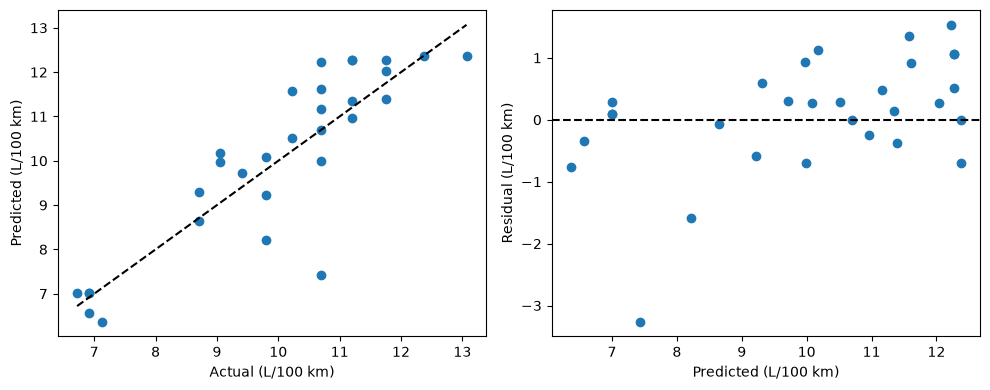

,model,split,subgroup_field,subgroup,n,mae,rmse,median_absolute_error,bias,small_support
0,dummy,test,vehicle_class,Compact Cars,5,2.488111,2.491445,2.490507,2.488111,True
1,dummy,test,vehicle_class,Minicompact Cars,4,0.690992,0.780887,0.544478,-0.342526,True
2,dummy,test,vehicle_class,Small Sport Utility Vehicle 2WD,6,1.092400,1.301500,1.050563,-1.092400,True
3,dummy,test,vehicle_class,Small Sport Utility Vehicle 4WD,4,1.677559,1.734674,1.537550,-1.677559,True
4,dummy,test,vehicle_class,Standard Sport Utility Vehicle 4WD,5,2.513279,2.614232,2.352146,-2.513279,True
...,...,...,...,...,...,...,...,...,...,...
87,tree,test,engine_size_bin,"(3,4] L",14,0.684831,0.824418,0.584251,-0.646214,True
88,tree,train_oof,engine_size_bin,"(0,2] L",50,0.836539,1.074170,0.615831,0.304453,False
89,tree,train_oof,engine_size_bin,"(2,3] L",36,1.560658,1.899307,1.275512,0.215046,False
90,tree,train_oof,engine_size_bin,"(3,4] L",22,1.272774,1.672885,0.875361,0.597204,True


,vehicle_id,model,split,model_year,manufacturer,model_name,displacement_l,cylinders,transmission,drivetrain,vehicle_class,engine_size_bin,y_true,y_pred,residual,abs_error
0,35952,dummy,test,2015,Ford,Flex AWD,3.5,6,Automatic (S6),All-Wheel Drive,Standard Sport Utility Vehicle 4WD,"(3,4] L",13.067477,9.408583,-3.658894,3.658894
1,35951,dummy,test,2015,Ford,Flex AWD,3.5,6,Automatic (S6),All-Wheel Drive,Standard Sport Utility Vehicle 4WD,"(3,4] L",12.379715,9.408583,-2.971132,2.971132
2,48493,dummy,test,2025,Toyota,Corolla,2.0,4,Automatic (variable gear ratios),Front-Wheel Drive,Compact Cars,"(0,2] L",6.720417,9.408583,2.688167,2.688167
3,48494,dummy,test,2025,Toyota,Corolla,2.0,4,Automatic (variable gear ratios),Front-Wheel Drive,Compact Cars,"(0,2] L",6.918076,9.408583,2.490507,2.490507
4,48495,dummy,test,2025,Toyota,Corolla,2.0,4,Automatic (AV-S10),Front-Wheel Drive,Compact Cars,"(0,2] L",6.918076,9.408583,2.490507,2.490507
5,48496,dummy,test,2025,Toyota,Corolla FX,2.0,4,Automatic (variable gear ratios),Front-Wheel Drive,Compact Cars,"(0,2] L",6.918076,9.408583,2.490507,2.490507
6,35048,dummy,test,2015,Honda,Pilot 2WD,3.5,6,Automatic 5-spd,Front-Wheel Drive,Small Sport Utility Vehicle 2WD,"(3,4] L",11.760729,9.408583,-2.352146,2.352146
7,35054,dummy,test,2015,Honda,Pilot 4WD,3.5,6,Automatic 5-spd,All-Wheel Drive,Small Sport Utility Vehicle 4WD,"(3,4] L",11.760729,9.408583,-2.352146,2.352146
8,47755,dummy,test,2025,Honda,Pilot AWD TrailSport,3.5,6,Automatic (S10),All-Wheel Drive,Standard Sport Utility Vehicle 4WD,"(3,4] L",11.760729,9.408583,-2.352146,2.352146
9,42094,dummy,test,2020,Toyota,Corolla Hatchback XSE,2.0,4,Automatic (AV-S10),Front-Wheel Drive,Compact Cars,"(0,2] L",7.127715,9.408583,2.280869,2.280869


In [7]:
predictions = pd.read_csv(TABLES / "predictions.csv")
best = predictions.loc[predictions.model.eq(run_info["selected_model"]) & predictions["split"].eq("test")]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(best.y_true, best.y_pred); bounds=[best.y_true.min(),best.y_true.max()]
axes[0].plot(bounds,bounds,"k--"); axes[0].set(xlabel="Actual (L/100 km)",ylabel="Predicted (L/100 km)")
axes[1].scatter(best.y_pred,best.residual); axes[1].axhline(0,color="black",linestyle="--")
axes[1].set(xlabel="Predicted (L/100 km)",ylabel="Residual (L/100 km)")
plt.tight_layout(); plt.show()
display(pd.read_csv(TABLES / "subgroup_errors.csv"))
display(pd.read_csv(TABLES / "large_errors.csv").head(10))

## Выводы и следующий этап

Этот прогон проверяет работоспособность pipeline. Его метрики не используются для утверждения точности на полном каталоге. Следующий шаг — полный collection, не менее 1 000 пригодных конфигураций, audit категорий/дублей и новый benchmark freeze. Для Endterm после полноценных результатов проверим ансамбли/tuning, PCA/clustering и MLP. На Final сравним исходные model/engine text на тех же IDs. Фактический вклад и AI помощь фиксируются в docs/CONTRIBUTIONS.md.

In [8]:
print({"dataset_sha256":run_info["dataset_sha256"], "split_sha256":run_info["split_sha256"],
       "python":run_info["python_version"], "packages":run_info["package_versions"],
       "development_small_dataset":run_info["development_small_dataset"]})

{'dataset_sha256': 'f03e84f68e8e15daab31e6a1ce6e1e0886e5c33bac95a551ec5ecc6d19bfb665', 'split_sha256': '670cddb2508c011e750aed105eef6ba79c46ba144e8e91bd1067ab983098cb4a', 'python': '3.12.14', 'packages': {'numpy': '2.5.3', 'pandas': '3.0.6', 'scikit-learn': '1.9.1', 'joblib': '1.6.0'}, 'development_small_dataset': True}
